# What is the most optimal skill to learn for Data Analysts?

In [1]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\HP\Documents\Learning Data Analytics\Python\Luke's Tutorial\Python_Data_Analytics_Course-main\data_jobs.csv")

In [3]:
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [4]:
def clean_list(skill_list):
    if pd.notna(skill_list):
       return ast.literal_eval(skill_list)

df['job_skills'] = df['job_skills'].apply(clean_list)

In [6]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()
df_DA_US = df_DA_US.dropna(subset = ['salary_year_avg'])

In [8]:
df_DA_US_explode = df_DA_US.explode('job_skills')

In [10]:
df_DA_US_explode[['salary_year_avg', 'job_skills']].head()

,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel


In [17]:
df_DA_skills = df_DA_US_explode.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values('count', ascending = False)
df_DA_skills = df_DA_skills.rename(columns = {'count':'skill_count','median':'median_salary'})
DA_job_count = len(df_DA_US)
df_DA_skills['skill_percent'] = (df_DA_skills['skill_count'] / DA_job_count) * 100
df_DA_skills

,skill_count,median_salary,skill_percent
job_skills,,,
sql,2508,91000.0,57.655172
excel,1808,84392.0,41.563218
python,1431,97500.0,32.896552
tableau,1364,92875.0,31.356322
sas,926,90000.0,21.287356
...,...,...,...
theano,1,100000.0,0.022989
typescript,1,65000.0,0.022989
vmware,1,147500.0,0.022989


In [20]:
skill_percent = 5
df_DA_skills = df_DA_skills[df_DA_skills['skill_percent'] > skill_percent]

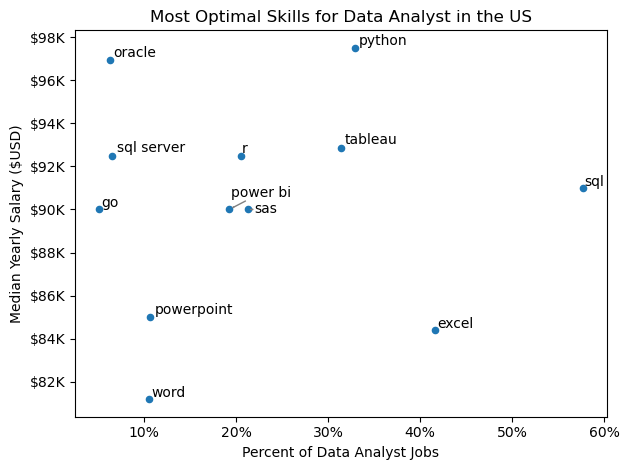

In [32]:
from adjustText import adjust_text
from matplotlib.ticker import PercentFormatter

df_DA_skills.plot(kind = 'scatter', x = 'skill_percent', y = 'median_salary')

texts = []

for i, txt in enumerate(df_DA_skills.index):
    texts.append(plt.text(df_DA_skills['skill_percent'].iloc[i],df_DA_skills['median_salary'].iloc[i], txt))

adjust_text(texts, arrowprops = dict(arrowstyle="->", color = 'grey', lw = 1))

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f"${int(y/1000)}K"))
ax.xaxis.set_major_formatter(PercentFormatter(decimals = 0))

plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary ($USD)')
plt.title('Most Optimal Skills for Data Analyst in the US')
plt.tight_layout() 
    
plt.show()

In [33]:
df['job_type_skills'].head(10)

0                                                  NaN
1    {'analyst_tools': ['power bi', 'tableau'], 'pr...
2    {'analyst_tools': ['dax'], 'cloud': ['azure'],...
3    {'cloud': ['aws'], 'libraries': ['tensorflow',...
4    {'cloud': ['oracle', 'aws'], 'other': ['ansibl...
5    {'cloud': ['gcp'], 'programming': ['python', '...
6    {'cloud': ['gcp', 'bigquery'], 'databases': ['...
7    {'cloud': ['gcp', 'azure', 'aws', 'bigquery', ...
8    {'analyst_tools': ['excel', 'powerpoint', 'pow...
9    {'analyst_tools': ['excel'], 'cloud': ['azure'...
Name: job_type_skills, dtype: object

In [34]:
df_technology = df['job_type_skills'].copy()

# remove duplicates
df_technology = df_technology.drop_duplicates()

# remove NaN values
df_technology = df_technology.dropna()

# combine all dictionaries into one
technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row)  # convert string to dictionary
    for key, value in row_dict.items():
        if key in technology_dict:  # if key already exists in technology_dict, add value to existing value
            technology_dict[key] += value
        else:                       # if key does not exist in technology_dict, add key and value
            technology_dict[key] = value

# remove duplicates by converting values to set then back to list
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

technology_dict

{'analyst_tools': ['powerpoint',
  'sharepoint',
  'powerbi',
  'excel',
  'sas',
  'ssis',
  'datarobot',
  'microstrategy',
  'splunk',
  'ms access',
  'nuix',
  'tableau',
  'alteryx',
  'spreadsheet',
  'visio',
  'sheets',
  'spss',
  'outlook',
  'power bi',
  'word',
  'looker',
  'ssrs',
  'qlik',
  'dax',
  'sap',
  'msaccess',
  'esquisse',
  'cognos'],
 'programming': ['sql',
  'clojure',
  'julia',
  'visual basic',
  'crystal',
  'kotlin',
  'apl',
  'r',
  'sas',
  'nosql',
  'matlab',
  'ruby',
  'perl',
  'c',
  'javascript',
  'swift',
  'bash',
  'no-sql',
  'haskell',
  'php',
  'visualbasic',
  'pascal',
  'vb.net',
  'f#',
  't-sql',
  'golang',
  'lisp',
  'dart',
  'mongo',
  'cobol',
  'c++',
  'typescript',
  'java',
  'lua',
  'ocaml',
  'fortran',
  'groovy',
  'powershell',
  'mongodb',
  'css',
  'go',
  'rust',
  'erlang',
  'python',
  'objective-c',
  'elixir',
  'c#',
  'delphi',
  'html',
  'assembly',
  'shell',
  'solidity',
  'vba',
  'sass',
  'sc

In [38]:
df_technology = pd.DataFrame(list(technology_dict.items()), columns = ['technology','skills'])

df_technology = df_technology.explode('skills')

df_technology

,technology,skills
0,analyst_tools,powerpoint
0,analyst_tools,sharepoint
0,analyst_tools,powerbi
0,analyst_tools,excel
0,analyst_tools,sas
...,...,...
9,sync,symphony
9,sync,slack
9,sync,microsoft teams
9,sync,twilio


In [41]:
df_plot = df_DA_skills.merge(df_technology, left_on = 'job_skills', right_on = 'skills')

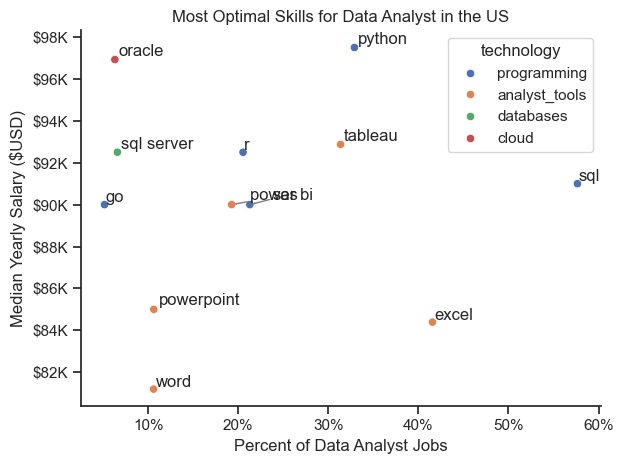

In [44]:
from adjustText import adjust_text
from matplotlib.ticker import PercentFormatter

# df_DA_skills.plot(kind = 'scatter', x = 'skill_percent', y = 'median_salary')
sns.scatterplot(data = df_plot, x = 'skill_percent', y = 'median_salary', hue = 'technology')
sns.set_theme(style = 'ticks')
sns.despine()

texts = []

for i, txt in enumerate(df_DA_skills.index):
    texts.append(plt.text(df_DA_skills['skill_percent'].iloc[i],df_DA_skills['median_salary'].iloc[i], txt))

adjust_text(texts, arrowprops = dict(arrowstyle="->", color = 'grey', lw = 1))

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f"${int(y/1000)}K"))
ax.xaxis.set_major_formatter(PercentFormatter(decimals = 0))

plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary ($USD)')
plt.title('Most Optimal Skills for Data Analyst in the US')
plt.tight_layout() 
    
plt.show()